In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

## Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon
from shapely.geometry import GeometryCollection

In [5]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

In [6]:
def clean_non_polygons(gdf):
    """
    Clean Geometry Collections and MultiPolygons by keeping only Polygons inside
    and dropping points or lines etc.
    """
    def _clean_geom(geom):
        if geom is None:
            return GeometryCollection()
        
        # If it's already a Polygon, return as is
        if geom.geom_type == 'Polygon':
            return geom

        # Get polygons from MultiPolygon or GeometryCollection 
        polygons = []
        if hasattr(geom, 'geoms'):
            for g in geom.geoms:
                if g.geom_type == 'Polygon':
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return GeometryCollection()
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and set invalid geometries to None
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf

In [7]:
def difference_overlay_without_discard(gdf1, gdf2):
    overlay_gdf = gpd.overlay(
        gdf1.reset_index(names="original_index"),
        gdf2,
        how="difference",
        keep_geom_type=True,
    )

    # Create a copy to modify
    gdf1_v2 = gdf1.copy()
    # By default, set all geometries to an empty Polygon
    gdf1_v2["geometry"] = GeometryCollection()
    # Update the geometries for the rows that still exist after the overlay
    gdf1_v2.loc[overlay_gdf["original_index"], "geometry"] = overlay_gdf.geometry.values

    gdf1_v2 = clean_non_polygons(gdf1_v2)

    return gdf1_v2


# def remove_geometry_difference(gdf, overlap_gdf):
#     # will need to keep track of original indices to replace geometries correctly
#     return_gdf = gdf.reset_index(names="original_index")

#     # perform difference operation. Note: drops fully overlapped geometries.
#     trimmed_geometries_gdf = gpd.overlay(
#         return_gdf,
#         overlap_gdf,
#         how="difference",
#         keep_geom_type=True,
#     )

#     # Get indices of geometries that were dropped (fully overlapped)
#     indices_of_dropped_geometries = list(
#         set(return_gdf.index) - set(trimmed_geometries_gdf["original_index"])
#     )

#     # update the geometries in the original gdf (replace with difference geometries or empty geometries)
#     return_gdf.loc[trimmed_geometries_gdf["original_index"], "geometry"] = (
#         trimmed_geometries_gdf["geometry"]
#     )
#     return_gdf.loc[indices_of_dropped_geometries, "geometry"] = (
#         shapely.geometry.Polygon()
#     )

#     # clean up any geometry collections or multipolygons
#     return_gdf = clean_geometry(return_gdf)

#     return return_gdf.drop(columns=["original_index"])

In [8]:
LOCATION = "Morena 2"

In [9]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
)
OUTPUT_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v4"
)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 0. Load cleaned khasras

In [10]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
morena_gdf = gpd.read_parquet(
    PROCESSED_DATA_DIR / "Cleaned Khasras" / "morena_cleaned_khasras.parquet"
)
morena_gdf

,Khasra ID (Unique),geometry,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,Noiyat Unusable Area (ha),Original Area (ha),Noiyat Unusable Area (%)
0,1 (Andhupura),"POLYGON ((77.36208 26.11041, 77.36232 26.11075...",1,Vijaypur Khasras,SEO3049,Vijaypur,03380,Andhupura,46020100028160,16.4900पहाड 16.4900 16.4900,1,0.00,13.460888,0.0
1,1 (Bara kalan),"POLYGON ((77.38585 26.13209, 77.38552 26.13196...",1,Vijaypur Khasras,SEO3130,Vijaypur,03380,Bara kalan,46020100031169,3.8140पहाड 3.8140 3.8140,1,0.00,3.193237,0.0
2,1 (Barhana),"POLYGON ((77.79261 26.52551, 77.79241 26.52558...",1,Joura Khasras,MRA2233,Joura,03388,Barhana,01030600090137,चारागाह 3.9000,1,0.00,4.710804,0.0
3,1 (Barkheda),"POLYGON ((77.34230 26.04357, 77.34205 26.04380...",1,Vijaypur Khasras,SEO2789,Vijaypur,03380,Barkheda,46020100021145,4.5500पठार 4.5500 4.5500,1/मिन-1,13.65,4.338877,100.0
4,1 (Bharkhoh),"POLYGON ((77.34889 26.11283, 77.34888 26.11286...",1,Vijaypur Khasras,SEO3047,Vijaypur,03380,Bharkhoh,46020100026158,1.3500पहाड 1.3500 1.3500,1,0.00,1.279301,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7563,Unit III (0),"POLYGON ((77.65337 25.96200, 77.65306 25.96213...",Unit III,Solar Park Boundary,0,None,None,0,None,None,None,0.00,11.383233,0.0
7564,Unit III (1),"POLYGON ((77.67168 25.95088, 77.67173 25.95193...",Unit III,Solar Park Boundary,1,None,None,1,None,None,None,0.00,227.179405,0.0
7565,Unit III (5),"POLYGON ((77.66333 25.96044, 77.66289 25.96047...",Unit III,Solar Park Boundary,5,None,None,5,None,None,None,0.00,212.248952,0.0
7566,Unit III (6),"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III,Solar Park Boundary,6,None,None,6,None,None,None,0.00,5.831037,0.0


In [12]:
gdf_4326 = morena_gdf
gdf = morena_gdf.to_crs(INDIA_PROJECTED_CRS)

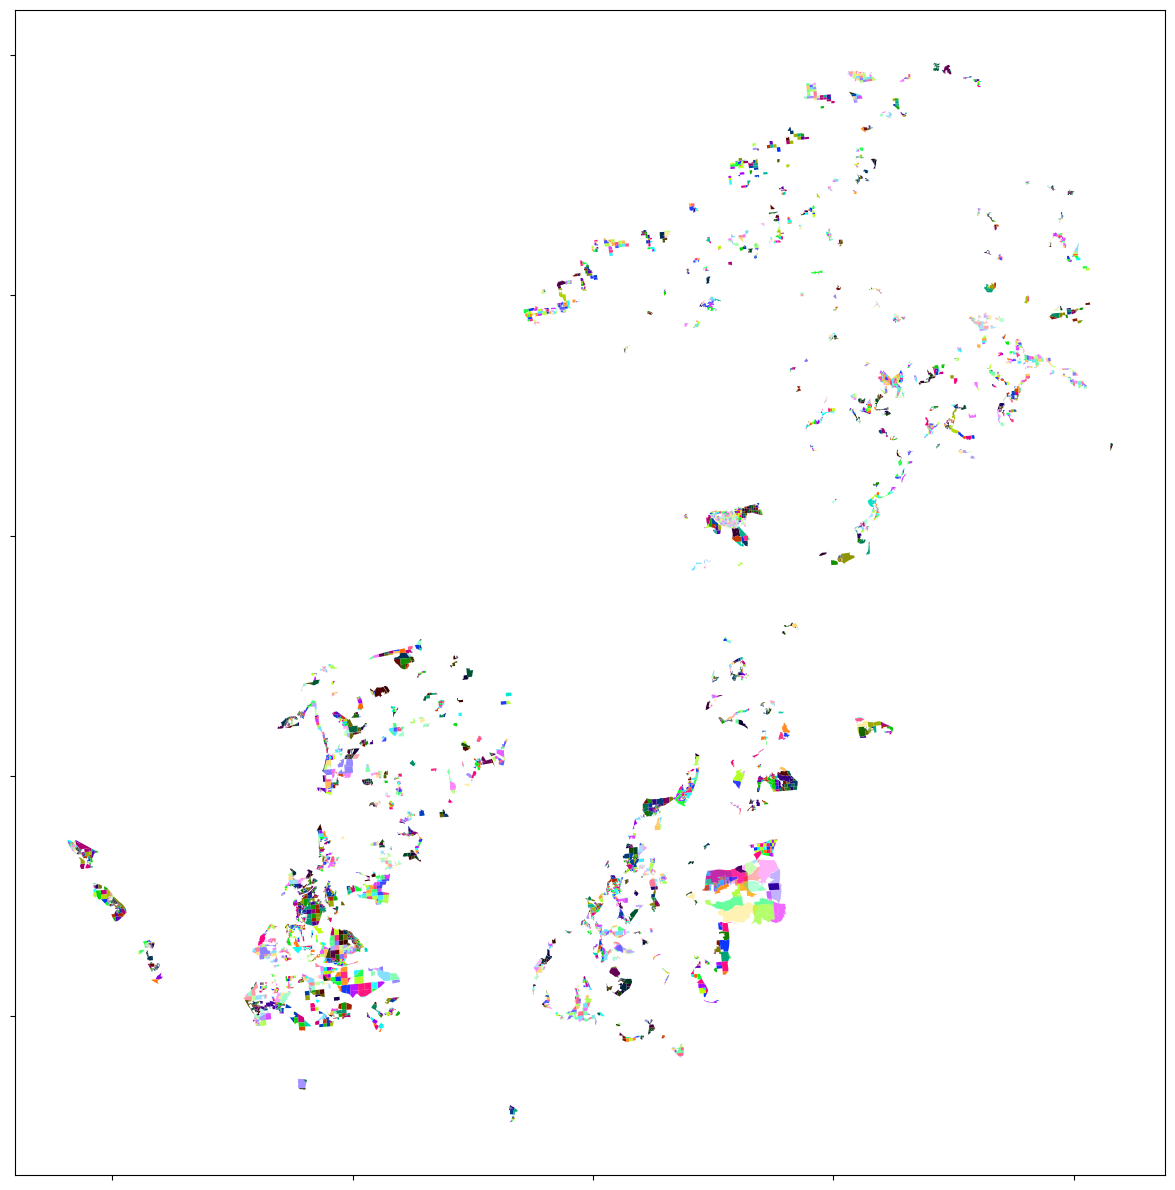

In [13]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [14]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

In [15]:
# get a centroid version of gdf
gdf_centroids = gdf.copy()
gdf_centroids.geometry = gdf_centroids.geometry.centroid

save_shapefiles(
    gdf_centroids[["Khasra ID", "geometry"]].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial_centroids",
    formats=["kml"],
)

In [16]:
# for Google Earth display - can't colour by the categorical column :(
save_shapefiles(
    gdf[(gdf["Noiyat Unusable Area (%)"] > 50)].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial_above_50pct_noiyat_unusable",
    formats=["kml"],
)
save_shapefiles(
    gdf[(gdf["Noiyat Unusable Area (%)"] <= 50)].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial_below_50pct_noiyat_unusable",
    formats=["kml"],
)

In [17]:
# add 0%, 50%, 100% mapped categorical column
labels = ["0%", "1-50%", "51-99%", "100%"]
intervals = [-0.01, 1, 50, 99, 100]

noiyat_unusable_area_category = pd.cut(
    gdf["Noiyat Unusable Area (%)"],
    bins=intervals,
    labels=labels,
    include_lowest=True,
)

noiyat_stats = noiyat_unusable_area_category.value_counts().loc[
    ["0%", "1-50%", "51-99%", "100%"]
]
noiyat_stats.to_csv(OUTPUT_DATA_DIR / "noiyat_stats.csv")
noiyat_stats

Noiyat Unusable Area (%)
0%        7052
1-50%       59
51-99%     191
100%       266
Name: count, dtype: int64

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [18]:
from gridsample.utils_rooftop import (
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
    download_VIDA_rooftops_data_by_s2,
    get_matched_rooftop_centroids_from_s2_file,
)

#### Identify S2 cell IDs

In [19]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 2
Unique S2 cell IDs: [4139089532530196480, 4140778382390460416]


/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


#### Check if identified cells cover all areas of interest


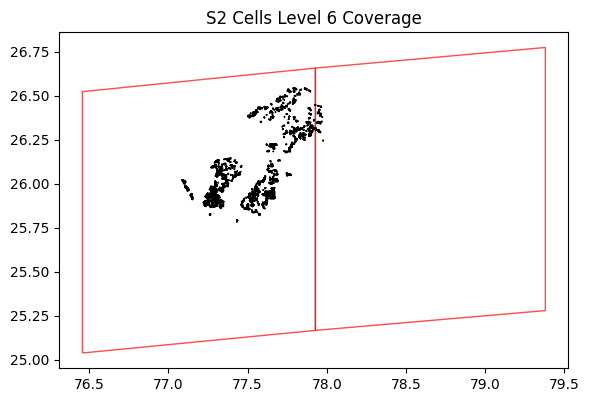

0.0 square degrees area not covered by an S2 cell


In [20]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [21]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4139089532530196480 already exists.
File 4140778382390460416 already exists.


#### Load and process rooftop data

In [22]:
try:
    print("Attempting to read pre-processed rooftop data...")
    subset_rooftops_gdf = gpd.read_parquet(PROCESSED_DATA_DIR / "Filtered Rooftops" / "rooftops.parquet")
    print("Rooftop data found and loaded.")
except FileNotFoundError:
    print("No rooftop data found. Processing...")
    rooftop_gdf_list = []
    for s2_cell_id in s2_cell_ids:
        s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
        rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
        rooftop_gdf_list.append(rooftop_gdf)

    rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
    rooftop_gdf = rooftop_gdf[
        [
            "bf_source",
            "confidence",
            "area_in_meters",
            "geometry",
        ]
    ]

    rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
    rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

    # Filter to only rooftops that overlap the parcels
    subset_rooftops_gdf = rooftop_gdf.sjoin(gdf, how="inner", predicate="intersects").drop(
        columns=["index_right"]
    )
    subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

    save_shapefiles(
        subset_rooftops_gdf,
        PROCESSED_DATA_DIR / "Filtered Rooftops",
        "rooftops",
        formats=["parquet"],
    )

Attempting to read pre-processed rooftop data...
Rooftop data found and loaded.


In [23]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(buffered_rooftops_gdf, gdf, how="intersection")

#### Settlements - auto

In [24]:
from sklearn.cluster import DBSCAN

In [25]:
# # DIFFERENT: min_samples changed to 10
# for eps in [200, 250, 300]:
#     clusterer = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
#     building_centroids = buildings_overlap_gdf.geometry.centroid
#     X = np.array(list(zip(building_centroids.x, building_centroids.y)))
#     building_cluster_ids = clusterer.fit_predict(X)
#     buildings_overlap_gdf["settlement_id"] = building_cluster_ids

#     settlement_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] != -1
#     ]
#     isolated_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] == -1
#     ]

#     # get the convex hull of each cluster
#     settlements_gdf = settlement_buildings_gdf.dissolve(
#         by="settlement_id"
#     ).reset_index()
#     settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
#     settlements_gdf.geometry = settlements_gdf.convex_hull

#     # get cutout of the buffered building shapes that overlap parcels
#     settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
#     settlements_gdf = settlements_gdf[["Khasra ID", "settlement_id", "geometry"]]

#     # plot
#     ax = gdf.plot(figsize=(20, 20))
#     settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
#     settlement_buildings_gdf.plot(ax=ax, color="red")
#     isolated_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

#     # add stats
#     total_count = len(buildings_overlap_gdf)
#     settlement_count = len(settlement_buildings_gdf)
#     perc_settlement_buildings = settlement_count / total_count * 100
#     isolated_count = len(isolated_buildings_gdf)
#     total_area = buildings_overlap_gdf.area.sum() / 10_000
#     settlement_area = settlements_gdf.area.sum() / 10_000
#     title = f"""
#     Buildings at {eps}m eps
#     Total Buildings: {total_count}
#     Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
#     Total Building Area (ha): {total_area:.2f}
#     Settlement Area (ha): {settlement_area:.2f}
#     """
#     ax.set_title(title, fontsize=12)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     plt.savefig(
#         DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png",
#         dpi=300,
#         bbox_inches="tight",
#     )

In [26]:
CHOSEN_EPS = 200
MIN_BUILDINGS = 10
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=MIN_BUILDINGS, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
isolated_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_78792/3396647236.py:22: UserWarning: `keep_geom_type=True` in overlay resulted in 3 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")


In [27]:
building_counts_df = (
    buildings_overlap_gdf.groupby("Khasra ID (Unique)")
    .size()
    .reset_index(name="Building Count")
)
building_counts_df

,Khasra ID (Unique),Building Count
0,1 (Barkheda),4
1,1 (Bharkhoh),4
2,1 (Deora),19
3,1 (Jhar baroda),1
4,1 (Malikpur),2
...,...,...
1725,Unit II (7),1
1726,Unit III (0),2
1727,Unit III (1),1
1728,Unit III (5),3


In [28]:
isolated_buildings_overlap_gdf = isolated_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [29]:
isolated_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = (
    isolated_buildings_overlap_gdf.area / 10_000
)
isolated_buildings_unusable_area_df = isolated_buildings_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Isolated Buildings (ha)"]
]

In [30]:
settlements_overlap_gdf = settlements_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = (
    settlements_overlap_gdf.area / 10_000
)
settlements_unusable_area_df = settlements_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Settlements (ha)"]
]

### Landcover (Cropland, Water)

#### Landcover

In [31]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [32]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [33]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

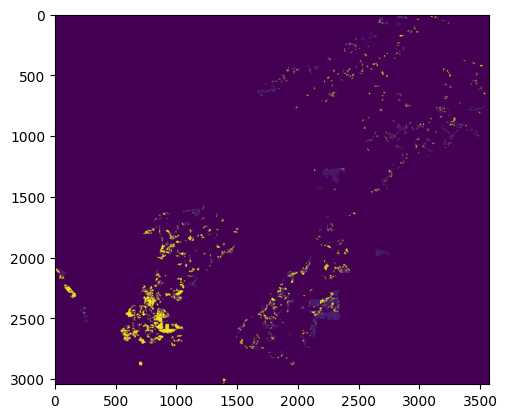

<Axes: >

In [34]:
masked_landcover_data, masked_transform = rasterio.mask.mask(
    src, [gdf.to_crs(4326).unary_union], crop=True
)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [35]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [36]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [37]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(cropland_shapes_gdf, gdf, how="intersection")
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [38]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = (
    cropland_overlap_gdf.area / 10_000
)
cropland_unusable_area_df = cropland_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Cropland (ha)"]
]

#### Water

In [39]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [40]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(water_shapes_gdf, gdf, how="intersection")
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [41]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Water (ha)"]
]

#### Trees

In [42]:
# tree_shapes_gdf = get_landcover_shapes(
#     masked_landcover_data,
#     masked_transform,
#     class_name="Tree cover",
#     class_value_lookup_dict=landcover_class_value_dict,
#     raster_crs=src.crs,
#     target_crs=INDIA_PROJECTED_CRS,
# )

In [43]:
# # get cutout of the tree shapes that overlap parcels
# tree_overlap_gdf = gpd.overlay(tree_shapes_gdf, gdf, how="intersection")
# tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [44]:
# tree_overlap_gdf.plot()

In [45]:
# tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
# tree_unusable_area_df = tree_overlap_gdf[
#     ["Khasra ID (Unique)", "Unusable Area - Tree Cover (ha)"]
# ]
# tree_unusable_area_df

### Load visually marked Dense Trees

In [46]:
import shapely

In [47]:
dense_trees_gdf = gpd.read_file(PROCESSED_DATA_DIR / "Dense Trees (Visual) v2.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
dense_trees_gdf.geometry = dense_trees_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
dense_trees_gdf.drop(columns=["Description"], inplace=True)
dense_trees_gdf.rename(columns={"Name": "Tree Patch"}, inplace=True)

In [48]:
dense_trees_gdf

,Tree Patch,geometry
0,1,"POLYGON ((3700074.367 220112.008, 3700070.111 ..."
1,2,"POLYGON ((3705210.253 230520.954, 3705396.855 ..."
2,3,"POLYGON ((3705982.229 231211.583, 3706025.772 ..."
3,4,"POLYGON ((3704977.202 232245.901, 3705001.472 ..."
4,5,"POLYGON ((3705000.818 232456.950, 3705060.463 ..."
5,6,"POLYGON ((3703888.249 233150.974, 3703892.263 ..."
6,7,"POLYGON ((3706712.146 238495.490, 3706521.472 ..."
7,8,"POLYGON ((3703504.075 225365.067, 3703309.206 ..."
8,9,"POLYGON ((3704016.339 233108.742, 3704074.760 ..."
9,10,"POLYGON ((3704266.900 237175.755, 3704260.194 ..."


In [49]:
dense_trees_overlap_gdf = gpd.overlay(dense_trees_gdf, gdf, how="intersection")
dense_trees_overlap_gdf = dense_trees_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()
dense_trees_overlap_gdf.head()

,Khasra ID (Unique),geometry,Tree Patch,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,Noiyat Unusable Area (ha),Original Area (ha),Noiyat Unusable Area (%)
0,100 (Budhera),"POLYGON ((3704183.161 236995.381, 3704170.592 ...",10,100,Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,कदीम 5.6120,100/मिन-5,0.0,1.033614,0.0
1,100 (Kamlapur),"MULTIPOLYGON (((3703662.847 233087.661, 370366...",6,100,Vijaypur Khasras,SEO2588,Vijaypur,03380,Kamlapur,46020300041191,0.5750पहाड 0.5750 0.5750,100,0.0,0.322271,0.0
2,101 (Kamlapur),"POLYGON ((3703604.521 233072.191, 3703604.763 ...",6,101,Vijaypur Khasras,SEO2588,Vijaypur,03380,Kamlapur,46020300041191,2.0480पत्थर 2.0480 2.0480,101,0.0,2.062026,0.0
3,110 (Budhera),"POLYGON ((3704298.864 236758.426, 3704301.151 ...",10,110,Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,पत्थर 0.3660,110,0.0,0.285528,0.0
4,140 (Budhera),"POLYGON ((3704363.861 237023.648, 3704452.563 ...",10,140,Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,कदीम 11.2860,140/मिन-4,0.0,15.465050,0.0


In [50]:
dense_trees_overlap_gdf["Unusable Area - Dense Trees (ha)"] = dense_trees_overlap_gdf.area / 10_000
dense_trees_unusable_area_df = dense_trees_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Dense Trees (ha)"]
]

### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [51]:
### SKIP THE NEXT CELL IF PYDEM IS NOT INSTALLED. PRE-PROCESSED SHAPES ARE SAVED TO FILE ALREADY.

In [52]:
from pydem.dem_processing import DEMProcessor

def get_steep_shapes(dem_filename):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    try:
        print("Trying to load pre-calculated slopes and aspects...")
        slope_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy"
        )
        aspect_pydem = np.load(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy"
        )
    except FileNotFoundError:
        print("Pre-calculated file not found. Calculating slopes and aspects...")
        slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
        np.save(
            RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem
        )
        np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)
    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # Display slope and aspect
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    # slope vis
    ax1.imshow(slope)
    ax1.set_title(f"{dem_filename} - Slope")
    ax2.hist(slope.flatten(), bins=100)
    ax2.set_title("Slope Histogram")
    # aspect vis
    ax3.imshow(aspect)
    ax3.set_title(f"{dem_filename} - Aspect")
    ax4.hist(aspect.flatten(), bins=100)
    ax4.set_title("Aspect Histogram")
    plt.tight_layout()
    plt.show()

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Plot the mask with a binary colormap and correct axes
    x_min = transform[2]
    x_max = x_min + transform[0] * slope_mask.shape[1]
    y_max = transform[5]
    y_min = y_max + transform[4] * slope_mask.shape[0]
    plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
    plt.colorbar(label="Aspect Mask", ax=ax)
    plt.title("Aspect Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    return slope_shapes_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pydem/dem_processing.py:76: RuntimeWarning: Cython functions are not compiled. UCA cannot be calculated. Consider compiling cython functions using: python setup.py build_ext --inplace
  warnings.warn("Cython functions are not compiled. UCA cannot be calculated."


In [53]:
try:
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes.parquet"
    )
    print("Loaded saved slope overlaps.")
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")

    dem_filenames = [
        "P5_PAN_CD_N25_000_E077_000_DEM_30m",
        "P5_PAN_CD_N26_000_E077_000_DEM_30m",
    ]
    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        steep_shapes_gdf = get_steep_shapes(dem_filename)
        steep_shapes_gdf_list.append(steep_shapes_gdf)
    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)
    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()
    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes",
        formats=["parquet"],
    )

Checking for existing slope overlaps...
Loaded saved slope overlaps.


<Axes: >

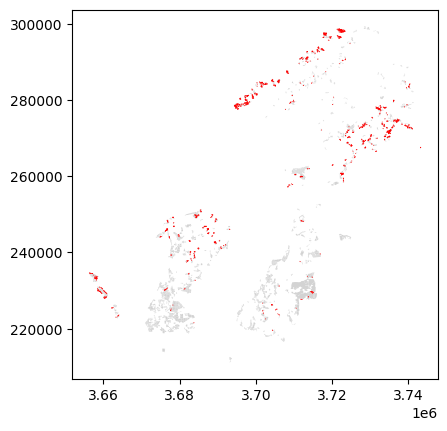

In [54]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

In [55]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Slope (ha)"]
]

### Get roads

In [56]:
# import osmnx as ox

In [57]:
# def get_osm_roads(
#     query: str, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph_from_place(query, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_bbox(
#     bbox, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_bbox(bbox=bbox, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_point(
#     point, dist, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_point(point, dist=dist, dist_type="bbox", network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()

In [58]:
# lat1, lon1 = 26.019683, 77.558542
# roads_gdf_lower = get_osm_roads_from_point((lat1, lon1), dist=45000, network_type="drive")


# lat2, lon2 = 26.449800, 77.777881
# roads_gdf_upper = get_osm_roads_from_point((lat2, lon2), dist=15000, network_type="drive")

# roads_gdf = pd.concat([roads_gdf_lower, roads_gdf_upper])
# roads_gdf.drop_duplicates(subset=["u", "v"], inplace=True)
# roads_gdf = roads_gdf.to_crs(INDIA_PROJECTED_CRS)

In [59]:
# ax=roads_gdf.plot()
# available_gdf.plot(ax=ax, facecolor="none", edgecolor="red")

In [60]:
# save_shapefiles(
#     roads_gdf.to_crs(epsg=4326),
#     OUTPUT_DATA_DIR,
#     "roads",
#     formats=["kml"],
# )

### Save individual layers

In [61]:
selected_Name_list = gdf["Khasra ID (Unique)"].unique()

In [62]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# dense trees
save_shapefiles(
    dense_trees_overlap_gdf.loc[
        dense_trees_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Dense Trees (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "dense_trees",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# isolated buildings
save_shapefiles(
    isolated_buildings_overlap_gdf.loc[
        isolated_buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "isolated_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [63]:
selected_foldername = "Layered"

#### Plots

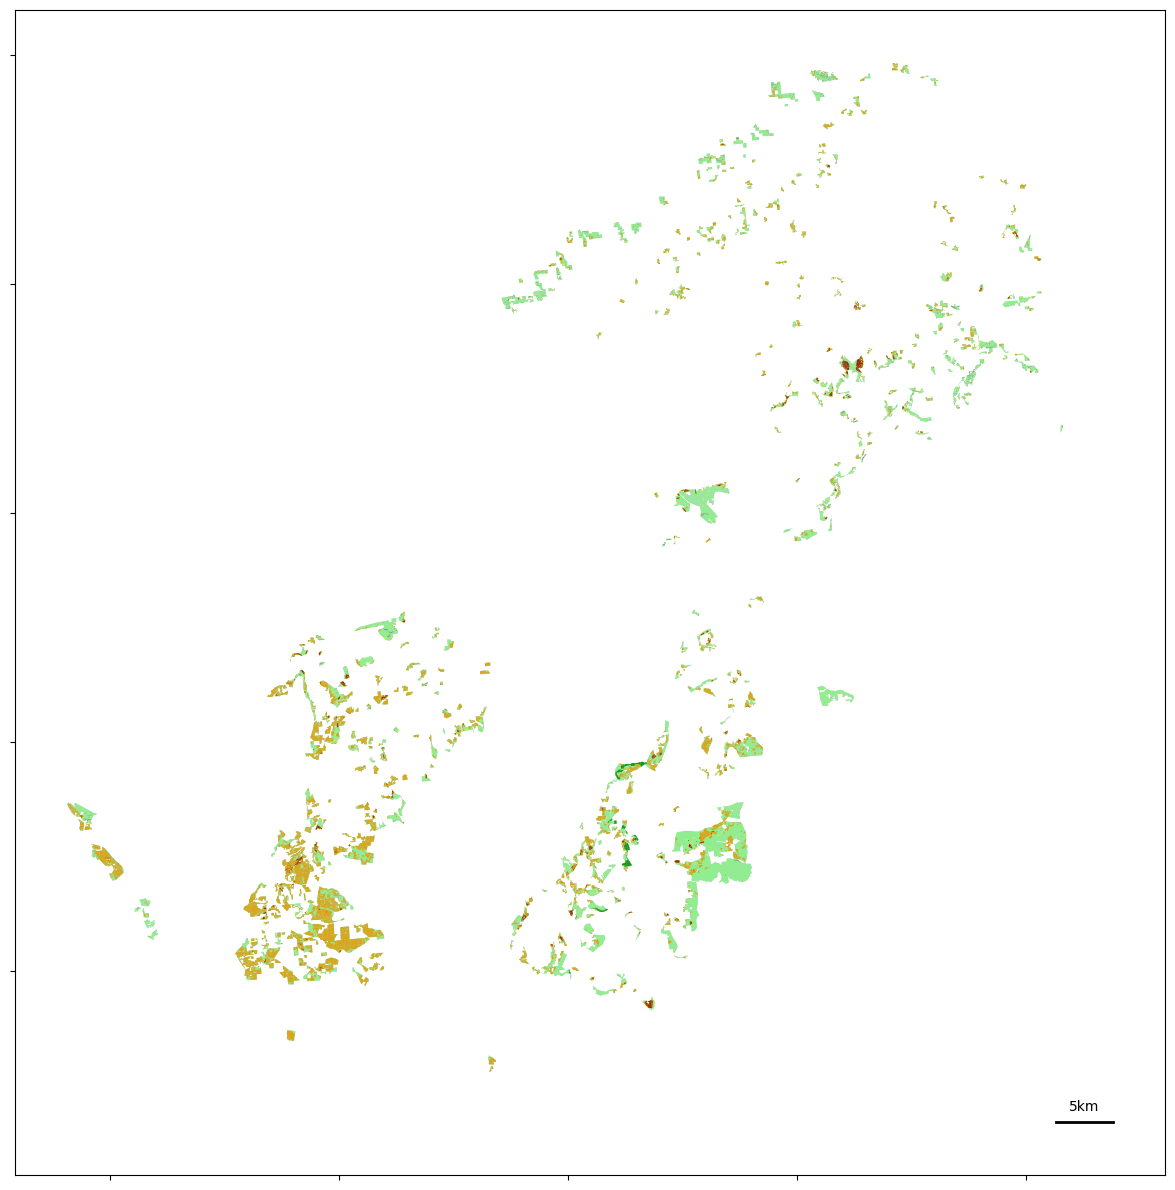

In [64]:
ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
gdf.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 5km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
# ax.plot(
#     [xmax - 1600, xmax - 1400],
#     [ymin + 250, ymin + 250],
#     color="white",
#     linewidth=7,
#     linestyle="-",
# )
ax.text(xmax - 2500, ymin + 1000, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[
    water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=WATER_COLOR, label="Water")

cropland_overlap_gdf[
    cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

dense_trees_overlap_gdf[
    dense_trees_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color="green", alpha=0.8, label="Dense Trees")

slope_overlap_gdf[
    slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg")

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "clusters_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

#### Calculate Areas

##### Cut out unusable

In [65]:
available_gdf = gdf.copy()

In [66]:
# cut out water
available_gdf = difference_overlay_without_discard(available_gdf, water_overlap_gdf)

# cut out settlements
available_gdf = difference_overlay_without_discard(available_gdf, settlements_overlap_gdf)

# cut out dense trees
available_gdf = difference_overlay_without_discard(available_gdf, dense_trees_overlap_gdf)

In [67]:
available_gdf["Usable Area (ha)"] = available_gdf.area / 10_000
available_gdf["Unusable Area (ha)"] = (
    available_gdf["Original Area (ha)"] - available_gdf["Usable Area (ha)"]
)

# percentages
available_gdf["Usable Area (%)"] = (
    available_gdf["Usable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)
available_gdf["Unusable Area (%)"] = (
    available_gdf["Unusable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)

In [68]:
# Final values (noiyat-adjusted)
available_gdf["Final Usable Area (ha)"] = available_gdf[
    "Usable Area (ha)"
] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)
available_gdf["Final Usable Area (%)"] = available_gdf["Usable Area (%)"] * (
    1 - available_gdf["Noiyat Unusable Area (%)"] / 100
)

In [69]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [70]:
# cut out cropland
available_gdf = difference_overlay_without_discard(
    available_gdf,
    cropland_overlap_gdf,
)

# cut out isolated buildings
available_gdf = difference_overlay_without_discard(
    available_gdf,
    isolated_buildings_overlap_gdf,
)

# cut out slopes
available_gdf = difference_overlay_without_discard(
    available_gdf,
    slope_overlap_gdf,
)

In [71]:
available_gdf["Usable and Available Area (ha)"] = available_gdf.area / 10_000
available_gdf["Usable but Unavailable Area (ha)"] = (
    available_gdf["Usable Area (ha)"]
    - available_gdf["Usable and Available Area (ha)"]
)

# percentages
available_gdf["Usable and Available Area (%)"] = (
    available_gdf["Usable and Available Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)
available_gdf["Usable but Unavailable Area (%)"] = (
    available_gdf["Usable but Unavailable Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)

In [72]:
# Final values
available_gdf["Final Usable and Available Area (ha)"] = available_gdf[
    "Usable and Available Area (ha)"
] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)
available_gdf["Final Usable and Available Area (%)"] = available_gdf[
    "Usable and Available Area (%)"
] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)

In [73]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(isolated_buildings_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(dense_trees_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(building_counts_df, on="Khasra ID (Unique)", how="outer").fillna(0)

# add onto the output and fill in null values with zeros (layer cols that don't overlap a given khasra will have null)
available_gdf = available_gdf.merge(all_unusable_area_cols_df, on="Khasra ID (Unique)", how="left")
available_gdf[all_unusable_area_cols_df.columns] = available_gdf[all_unusable_area_cols_df.columns].fillna(0)

In [74]:
ordered_columns = [
    # id
    "Khasra ID",
    "geometry",
    "Khasra ID (Unique)",
    "Source",
    "Patch Name",
    "Tehsil Name",
    "Tehsil Code",
    "Village Name",
    "BHU Code",
    "Noiyat",
    "ROR KID",
    # original area
    "Original Area (ha)",
    # Final areas
    "Final Usable Area (ha)",
    "Final Usable Area (%)",
    "Final Usable and Available Area (ha)",
    "Final Usable and Available Area (%)",
    # noiyat
    "Noiyat Unusable Area (ha)",
    "Noiyat Unusable Area (%)",
    # layered areas
    "Usable Area (ha)",
    "Usable and Available Area (ha)",
    "Usable but Unavailable Area (ha)",
    "Unusable Area (ha)",
    "Usable Area (%)",
    "Usable and Available Area (%)",
    "Usable but Unavailable Area (%)",
    "Unusable Area (%)",
    "Unusable Area - Settlements (ha)",
    "Unavailable Area - Isolated Buildings (ha)",
    "Unusable Area - Water (ha)",
    "Unavailable Area - Cropland (ha)",
    "Unusable Area - Dense Trees (ha)",
    "Unavailable Area - Slope (ha)",
    "Building Count",
]

available_gdf = available_gdf[ordered_columns]

In [75]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "kml", "csv"],
)

#### Replace geoms with original uncut geoms

In [76]:
# take a copy of the available_gdf without geometry for stats
gdf_with_stats = available_gdf.drop(columns="geometry").copy()
# assign the original geometries
gdf_with_stats["geometry"] = gdf.set_index("Khasra ID (Unique)").loc[
    gdf_with_stats["Khasra ID (Unique)"]
]["geometry"].values
gdf_with_stats = gdf_with_stats.set_geometry("geometry").set_crs(INDIA_PROJECTED_CRS)

In [77]:
save_shapefiles(
    gdf_with_stats.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_with_stats",
    formats=["parquet", "kml", "csv"],
)

In [78]:
gdf_with_stats

,Khasra ID,Khasra ID (Unique),Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,...,Usable but Unavailable Area (%),Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry
0,1,1 (Andhupura),Vijaypur Khasras,SEO3049,Vijaypur,03380,Andhupura,46020100028160,16.4900पहाड 16.4900 16.4900,1,...,8.590990,0.000000,0.000000,0.000000,0.0,1.156424,0.0,0.000000,0.0,"POLYGON ((3682968.445 246909.955, 3682989.096 ..."
1,1,1 (Bara kalan),Vijaypur Khasras,SEO3130,Vijaypur,03380,Bara kalan,46020100031169,3.8140पहाड 3.8140 3.8140,1,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,"POLYGON ((3685135.967 249524.576, 3685103.844 ..."
2,1,1 (Barhana),Joura Khasras,MRA2233,Joura,03388,Barhana,01030600090137,चारागाह 3.9000,1,...,5.179881,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.244014,0.0,"POLYGON ((3721830.291 296793.017, 3721808.933 ..."
3,1,1 (Barkheda),Vijaypur Khasras,SEO2789,Vijaypur,03380,Barkheda,46020100021145,4.5500पठार 4.5500 4.5500,1/मिन-1,...,23.405073,0.000000,0.000000,0.104845,0.0,0.943739,0.0,0.000000,4.0,"POLYGON ((3681638.759 239323.280, 3681612.048 ..."
4,1,1 (Bharkhoh),Vijaypur Khasras,SEO3047,Vijaypur,03380,Bharkhoh,46020100026158,1.3500पहाड 1.3500 1.3500,1,...,85.671146,12.437166,0.159109,0.000000,0.0,1.255101,0.0,0.000000,4.0,"POLYGON ((3681623.665 247062.752, 3681622.773 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7563,Unit III,Unit III (0),Solar Park Boundary,0,None,None,0,None,None,None,...,63.774871,0.000000,0.000000,0.371675,0.0,7.185979,0.0,0.000000,2.0,"POLYGON ((3713623.222 233060.942, 3713591.042 ..."
7564,Unit III,Unit III (1),Solar Park Boundary,1,None,None,1,None,None,None,...,18.223880,0.000000,0.000000,0.044676,0.0,41.356228,0.0,0.000000,1.0,"POLYGON ((3715571.392 231994.428, 3715564.935 ..."
7565,Unit III,Unit III (5),Solar Park Boundary,5,None,None,5,None,None,None,...,21.048179,0.000000,0.000000,0.600483,0.0,44.402450,0.0,0.000000,3.0,"POLYGON ((3714637.261 232978.319, 3714592.822 ..."
7566,Unit III,Unit III (6),Solar Park Boundary,6,None,None,6,None,None,None,...,54.594636,0.000000,0.000000,0.000000,0.0,3.183433,0.0,0.000000,0.0,"POLYGON ((3713862.974 232838.948, 3713903.017 ..."


## Get pivot statistics

In [92]:
def get_aggregate_gdf(areas_gdf: gpd.GeoDataFrame, cluster_id_col: str):
    pivot_df = (
        areas_gdf.drop(
            columns=[
                "Khasra ID",
                "Khasra ID (Unique)",
                "Tehsil Name",
                "Village Name",
                "BHU Code",
                "Noiyat",
                "ROR KID",
                "Noiyat Unusable Area (%)",
                "Final Usable Area (%)",
                "Final Usable and Available Area (%)",
                "Unusable Area (%)",
                "Usable Area (%)",
                "Usable and Available Area (%)",
                "Usable but Unavailable Area (%)",
                "geometry",
            ]
        )
        .groupby(cluster_id_col)
        .sum()
        .round(2)
    )
    # make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
    count_filtered_khasra_gdf = areas_gdf.groupby(cluster_id_col).agg(
        khasra_count=("Khasra ID (Unique)", "size"),
        khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x))),
    )
    count_filtered_khasra_gdf.rename(
        columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
        inplace=True,
    )
    # combine
    pivot_df = pivot_df.merge(
        count_filtered_khasra_gdf, on=cluster_id_col
    ).reset_index()

    # calculate % columns again

    # Noiyat layers
    pivot_df["Noiyat Unusable Area (%)"] = (
        pivot_df["Noiyat Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    # set max to 100 and min to 0 for any weird values
    pivot_df["Noiyat Unusable Area (%)"] = pivot_df["Noiyat Unusable Area (%)"].clip(
        0, 100
    )

    # Adjusted layers
    pivot_df["Final Usable Area (%)"] = (
        pivot_df["Final Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Final Usable and Available Area (%)"] = (
        pivot_df["Final Usable and Available Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)
    # IDi layers
    pivot_df["Unusable Area (%)"] = (
        pivot_df["Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable Area (%)"] = (
        pivot_df["Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable and Available Area (%)"] = (
        pivot_df["Usable and Available Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)
    pivot_df["Usable but Unavailable Area (%)"] = (
        pivot_df["Usable but Unavailable Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)

    pivot_df = pivot_df[
        [
            # id
            cluster_id_col,
            "Khasra Count",
            "Khasra IDs",
            # original area
            "Original Area (ha)",
            # Final areas
            "Final Usable Area (ha)",
            "Final Usable Area (%)",
            "Final Usable and Available Area (ha)",
            "Final Usable and Available Area (%)",
            # noiyat
            "Noiyat Unusable Area (ha)",
            "Noiyat Unusable Area (%)",
            # layered areas
            "Usable Area (ha)",
            "Usable and Available Area (ha)",
            "Usable but Unavailable Area (ha)",
            "Unusable Area (ha)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "Unusable Area (%)",
            "Unusable Area - Settlements (ha)",
            "Unavailable Area - Isolated Buildings (ha)",
            "Unusable Area - Water (ha)",
            "Unavailable Area - Cropland (ha)",
            "Unusable Area - Dense Trees (ha)",
            "Unavailable Area - Slope (ha)",
            "Building Count",
        ]
    ]

    # add the convex hull geometry
    convex_hull_geoms_gdf = (
        areas_gdf.dissolve(by=cluster_id_col)
        .convex_hull.to_frame(name="geometry")
        .reset_index()
    )
    pivot_df_with_geoms = pivot_df.merge(convex_hull_geoms_gdf, on=cluster_id_col)
    pivot_gdf = gpd.GeoDataFrame(pivot_df_with_geoms, geometry="geometry")

    return pivot_gdf

### Patch-level

In [93]:
patch_gdf = get_aggregate_gdf(gdf_with_stats, cluster_id_col="Patch Name")
patch_gdf

,Patch Name,Khasra Count,Khasra IDs,Original Area (ha),Final Usable Area (ha),Final Usable Area (%),Final Usable and Available Area (ha),Final Usable and Available Area (%),Noiyat Unusable Area (ha),Noiyat Unusable Area (%),...,Usable but Unavailable Area (%),Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry
0,0,1,Unit III (0),11.38,11.38,100.00,4.12,36.20,0.00,0.00,...,63.80,0.00,0.00,0.37,0.00,7.19,0.0,0.00,2.0,"POLYGON ((3713448.280 232684.859, 3713252.649 ..."
1,1,1,Unit III (1),227.18,227.18,100.00,185.78,81.78,0.00,0.00,...,18.22,0.00,0.00,0.04,0.00,41.36,0.0,0.00,1.0,"POLYGON ((3715403.994 229401.537, 3714645.879 ..."
2,10,1,Unit II (10),83.67,83.67,100.00,80.69,96.44,0.00,0.00,...,3.56,0.00,0.00,0.24,0.00,2.74,0.0,0.00,1.0,"POLYGON ((3712502.416 231064.497, 3712486.981 ..."
3,2,1,Unit II (2),48.54,48.54,100.00,48.31,99.53,0.00,0.00,...,0.49,0.00,0.00,0.24,0.00,0.00,0.0,0.00,2.0,"POLYGON ((3713108.423 229921.907, 3712811.505 ..."
4,3,1,Unit I (3),298.70,294.05,98.44,287.24,96.16,0.00,0.00,...,2.28,1.56,4.59,1.02,0.07,5.85,0.0,0.00,44.0,"POLYGON ((3710215.018 230341.368, 3709245.800 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,SEO3103,16,"71 (Garhi), 73 (Garhi), 74 (Garhi), 79 (Garhi)...",16.33,8.49,51.99,0.36,2.20,8.55,52.36,...,95.04,0.00,0.00,0.00,0.00,15.52,0.0,0.00,0.0,"POLYGON ((3677848.927 248564.554, 3677285.734 ..."
588,SEO3106,3,"1107/1 (Mewra), 1127 (Mewra), 1137 (Mewra)",7.63,7.63,100.00,5.31,69.59,0.00,0.00,...,30.41,0.00,0.00,0.25,0.00,1.47,0.0,0.67,1.0,"POLYGON ((3688386.010 249681.693, 3688378.291 ..."
589,SEO3107,3,"56 (Ahiri), 57 (Ahiri), 58 (Ahiri)",16.70,16.70,100.00,9.68,57.96,0.00,0.00,...,42.04,0.00,0.00,0.51,0.00,5.55,0.0,1.21,2.0,"POLYGON ((3678315.907 248883.370, 3678293.385 ..."
590,SEO3130,27,"1 (Bara kalan), 102 (Dongarpur (vijaypur)), 12...",254.91,254.89,99.99,229.11,89.88,0.34,0.13,...,10.11,0.00,0.00,2.72,0.00,12.84,0.0,10.57,24.0,"POLYGON ((3684239.503 248866.128, 3681316.878 ..."


In [94]:
save_shapefiles(
    patch_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Patch Shapefiles",
    "Patches",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 11.380000000000001.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 227.18000000000001.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 83.670000000000002.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 48.539999999999999.
  ogr

### Parcel(Manual)-level

In [95]:
import shapely

In [96]:
suggested_parcels_gdf = gpd.read_file(PROCESSED_DATA_DIR / "Suggested Parcels v4.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
suggested_parcels_gdf.geometry = suggested_parcels_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
suggested_parcels_gdf.drop(columns=["Description"], inplace=True)
suggested_parcels_gdf.rename(columns={"Name": "Parcel Name"}, inplace=True)

<Axes: >

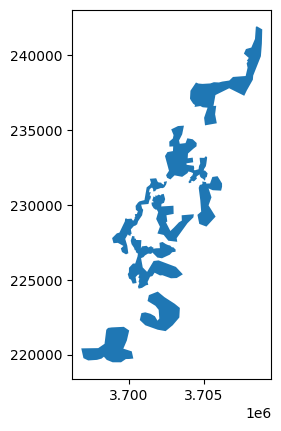

In [97]:
suggested_parcels_gdf.plot()

#### Merge into khasras and save to file

In [98]:
filtered_gdf_with_stats = gdf_with_stats.sjoin(suggested_parcels_gdf, predicate="within").drop(columns=["index_right"])
filtered_gdf_with_stats

,Khasra ID,Khasra ID (Unique),Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,...,Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry,Parcel Name
13,1,1 (Patpara),Vijaypur Khasras,SEO2798,Vijaypur,03380,Patpara,46020300042214,पहाड 5.7160,1,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,"POLYGON ((3708818.962 241628.751, 3708850.132 ...",8
42,100,100 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,कदीम 5.6120,100/मिन-5,...,100.0,0.0,0.0,0.0,0.000000,1.033614,0.0,0.0,"POLYGON ((3704195.778 236997.193, 3704180.771 ...",8
520,114,114 (Patpara),Vijaypur Khasras,SEO2762,Vijaypur,03380,Patpara,46020300042214,कदीम 0.6900,114,...,0.0,0.0,0.0,0.0,0.578441,0.000000,0.0,0.0,"POLYGON ((3707945.455 240166.693, 3707934.143 ...",8
542,115,115 (Patpara),Vijaypur Khasras,SEO2762,Vijaypur,03380,Patpara,46020300042214,कदीम 0.9720,115,...,0.0,0.0,0.0,0.0,0.543983,0.000000,0.0,0.0,"POLYGON ((3707917.925 240212.903, 3707908.096 ...",8
570,116,116 (Patpara),Vijaypur Khasras,SEO2762,Vijaypur,03380,Patpara,46020300042214,कदीम 0.0520,116,...,0.0,0.0,0.0,0.0,0.008288,0.000000,0.0,0.0,"POLYGON ((3707814.076 240139.244, 3707810.054 ...",8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6253,683,683 (Kinjari),Vijaypur Khasras,SEO2022,Vijaypur,03380,Kinjari,46020300047200,चट्टान 1.1600,683,...,0.0,0.0,0.0,0.0,0.182563,0.000000,0.0,0.0,"POLYGON ((3697526.072 220033.622, 3697496.548 ...",1
6258,684,684 (Kinjari),Vijaypur Khasras,SEO2022,Vijaypur,03380,Kinjari,46020300047200,कदीम 1.0000,684,...,0.0,0.0,0.0,0.0,0.589032,0.000000,0.0,0.0,"POLYGON ((3697418.020 219957.767, 3697416.734 ...",1
6271,689,689 (Kinjari),Vijaypur Khasras,SEO2022,Vijaypur,03380,Kinjari,46020300047200,चट्टान 1.3000,689,...,0.0,0.0,0.0,0.0,1.371484,0.000000,0.0,0.0,"POLYGON ((3697434.100 219881.262, 3697407.023 ...",1
6295,696,696 (Kinjari),Vijaypur Khasras,SEO2022,Vijaypur,03380,Kinjari,46020300047200,चट्टान 1.0900,696,...,0.0,0.0,0.0,0.0,1.004787,0.000000,0.0,0.0,"POLYGON ((3697456.365 219880.561, 3697434.100 ...",1


In [99]:
# move the "Parcel Name" column to earlier in the dataframe
filtered_gdf_with_stats = filtered_gdf_with_stats[
    [
        # ID
        "Khasra ID",
        "Parcel Name",
        "Village Name",
        "BHU Code",
        "Tehsil Name",
        "Noiyat",
        "ROR KID",
        "Patch Name",
        "Khasra ID (Unique)",
        # areas
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unusable Area - Dense Trees (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "geometry",
    ]
]

In [100]:
filtered_gdf_with_stats.sort_values(by=["Parcel Name", "Khasra ID"], inplace=True)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_78792/1331438235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_gdf_with_stats.sort_values(by=["Parcel Name", "Khasra ID"], inplace=True)


In [101]:
save_shapefiles(
    filtered_gdf_with_stats.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles" / "Morena 2 Filtered Khasras",
    "filtered_khasras_with_stats",
    formats=["parquet", "kml", "csv",  "geojson", "shp"],
)

/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils.py:487: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(folderpath / f"{filename}.shp", driver="ESRI Shapefile")
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Parcel Name' to 'Parcel Nam'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Village Name' to 'Village Na'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Tehsil Name' to 'Tehsil Nam'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Khasra ID (Unique)' to 'Khasra I_1'
  ogr_write(
/Users/amire

#### Pivot stats and save

In [102]:
parcel_gdf = get_aggregate_gdf(filtered_gdf_with_stats, cluster_id_col="Parcel Name")
parcel_gdf

,Parcel Name,Khasra Count,Khasra IDs,Original Area (ha),Final Usable Area (ha),Final Usable Area (%),Final Usable and Available Area (ha),Final Usable and Available Area (%),Noiyat Unusable Area (ha),Noiyat Unusable Area (%),...,Usable but Unavailable Area (%),Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry
0,1,69,"385 (Mohanpur (gaswani)), 396 (Kinjari), 399 (...",238.12,235.04,98.71,174.86,73.43,0.00,0.00,...,25.28,1.29,0.00,1.70,0.00,58.48,3.07,0.00,8.0,"POLYGON ((3699390.515 219530.859, 3698910.723 ..."
1,2,40,"1008 (Gaswani), 1013 (Gaswani), 1014 (Gaswani)...",173.74,172.94,99.54,150.00,86.34,0.80,0.46,...,13.44,0.00,0.00,0.48,0.00,22.85,0.00,0.11,3.0,"POLYGON ((3702196.066 221628.344, 3701183.202 ..."
2,3,148,"2252 (Gaswani), 2253 (Gaswani), 2335 (Gaswani)...",325.52,293.10,90.04,208.54,64.06,4.69,1.44,...,26.76,8.77,12.60,5.95,0.00,83.67,15.94,0.07,108.0,"POLYGON ((3700654.524 224446.236, 3700254.731 ..."
3,4,210,"120 (Enta), 122 (Enta), 124 (Enta), 158 (Enta)...",180.62,151.66,83.97,71.97,39.85,4.32,2.39,...,46.26,13.71,24.77,3.37,0.00,98.09,0.00,0.00,182.0,"POLYGON ((3699815.205 226755.822, 3699773.159 ..."
4,5,103,"109 (Kohera), 11 (Kohera), 111 (Kohera), 1278 ...",145.59,141.18,96.97,80.62,55.37,0.00,0.00,...,41.60,3.03,4.41,2.82,0.00,60.11,0.00,0.00,38.0,"POLYGON ((3702950.322 227638.782, 3702813.061 ..."
5,6,53,"1442 (Deori), 1443 (Deori), 1446 (Deori), 1447...",154.17,77.98,50.58,50.96,33.05,0.00,0.00,...,17.53,49.42,8.81,0.48,0.05,28.06,67.92,0.38,151.0,"POLYGON ((3705096.332 228677.984, 3705082.732 ..."
6,7,176,"100 (Kamlapur), 1003 (Deori), 1004 (Deori), 10...",346.36,318.66,92.00,188.37,54.39,0.08,0.02,...,37.62,7.97,6.32,3.22,0.35,133.23,20.94,0.00,51.0,"POLYGON ((3704015.999 231501.372, 3702691.377 ..."
7,8,210,"1 (Patpara), 100 (Budhera), 114 (Patpara), 115...",470.61,397.40,84.44,222.83,47.35,0.00,0.00,...,37.09,15.56,5.71,3.85,0.00,174.73,67.50,0.00,51.0,"POLYGON ((3705155.174 235461.155, 3704406.246 ..."


In [103]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Suggested Parcel Shapefiles",
    "Parcels",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 238.12.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 173.74000000000001.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 325.51999999999998.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 180.62.
  ogr_write(
/Users/amiremami

### Sgurr Parcel-level

In [204]:
suggested_parcels_gdf = gpd.read_file(
    PROCESSED_DATA_DIR / "Sgurr Parcels v1.kml"
).to_crs(epsg=INDIA_PROJECTED_CRS)
suggested_parcels_gdf.geometry = suggested_parcels_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
suggested_parcels_gdf.drop(columns=["Description"], inplace=True)
suggested_parcels_gdf.rename(columns={"Name": "Parcel Name"}, inplace=True)
suggested_parcels_gdf["Parcel Name"] = suggested_parcels_gdf["Parcel Name"].astype(int)

<Axes: >

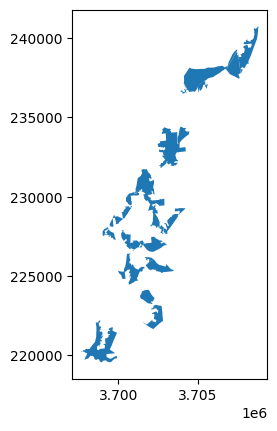

In [205]:
suggested_parcels_gdf.plot()

<Axes: >

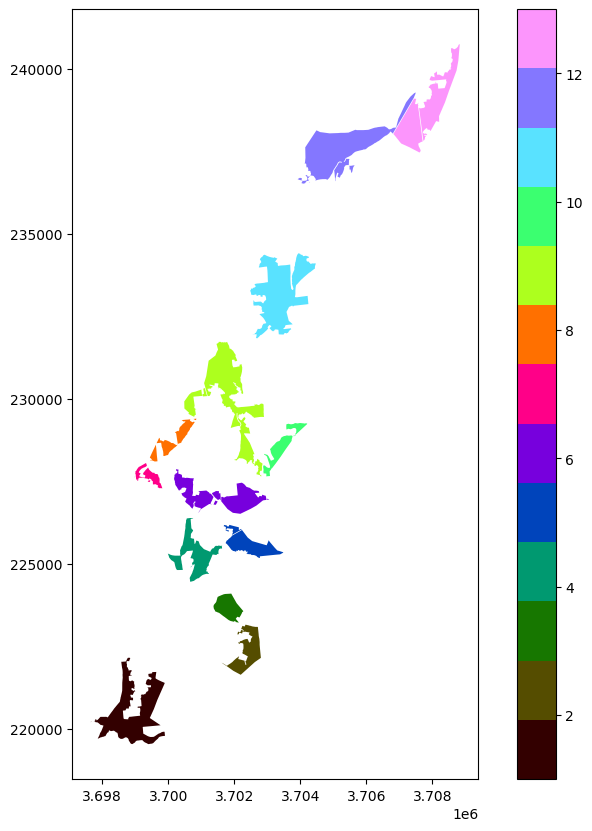

In [206]:
# Fix invalid geometries before dissolving
suggested_parcels_gdf["geometry"] = suggested_parcels_gdf["geometry"].buffer(-10)
suggested_parcels_gdf = suggested_parcels_gdf.dissolve(by="Parcel Name").reset_index()

suggested_parcels_gdf.plot(
    column="Parcel Name",
    cmap=ListedColormap(generate_colormap(len(suggested_parcels_gdf))),
    figsize=(10, 10),
    legend=True,
)


#### Merge into khasras and save to file

In [207]:
filtered_gdf_with_stats = gdf_with_stats.sjoin(suggested_parcels_gdf, predicate="intersects").drop(columns=["index_right"])
filtered_gdf_with_stats

,Khasra ID,Khasra ID (Unique),Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,...,Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry,Parcel Name
42,100,100 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,कदीम 5.6120,100/मिन-5,...,100.000000,0.0,0.0,0.0,0.000000,1.033614,0.0,0.0,"POLYGON ((3704195.778 236997.193, 3704180.771 ...",12
354,108,108 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,बुढ़ेल 1.2540,108,...,0.000000,0.0,0.0,0.0,0.004871,0.000000,0.0,0.0,"POLYGON ((3704232.695 236737.581, 3704224.715 ...",12
419,110,110 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,पत्थर 0.3660,110,...,19.154737,0.0,0.0,0.0,0.000000,0.054692,0.0,0.0,"POLYGON ((3704336.302 236751.502, 3704321.814 ...",12
564,116,116 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,पत्थर 0.2300,116,...,0.000000,0.0,0.0,0.0,0.051829,0.000000,0.0,0.0,"POLYGON ((3704246.857 236590.077, 3704255.703 ...",12
1046,139,139 (Budhera),Vijaypur Khasras,SEO2725,Vijaypur,03380,Budhera,46020300043216,पत्थर 12.6390,139,...,0.000000,0.0,0.0,0.0,3.808271,0.000000,0.0,0.0,"POLYGON ((3704983.608 236983.624, 3704979.622 ...",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7434,959,959 (Gaswani),Vijaypur Khasras,SEO2282,Vijaypur,03380,Gaswani,46020300046198,पहाड चटटान 13.2090,959,...,63.278865,0.0,0.0,0.0,0.637332,4.415853,0.0,0.0,"POLYGON ((3702783.508 225219.238, 3702773.970 ...",5
7452,960,960 (Gaswani),Vijaypur Khasras,SEO2282,Vijaypur,03380,Gaswani,46020300046198,पहाड चटटान 7.5240,960,...,1.170851,0.0,0.0,0.0,0.000000,0.067168,0.0,0.0,"POLYGON ((3702739.222 225641.924, 3702622.904 ...",5
7454,961,961 (Gaswani),Vijaypur Khasras,SEO2282,Vijaypur,03380,Gaswani,46020300046198,चट्टान 6.2800,961,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,"POLYGON ((3702490.336 225741.756, 3702451.471 ...",5
7484,973,973 (Gaswani),Vijaypur Khasras,SEO2282,Vijaypur,03380,Gaswani,46020300046198,चट्टान 9.7500,973,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,"POLYGON ((3703198.033 225534.368, 3703099.626 ...",5


In [208]:
# move the "Parcel Name" column to earlier in the dataframe
filtered_gdf_with_stats = filtered_gdf_with_stats[
    [
        # ID
        "Khasra ID",
        "Parcel Name",
        "Village Name",
        "BHU Code",
        "Tehsil Name",
        "Noiyat",
        "ROR KID",
        "Patch Name",
        "Khasra ID (Unique)",
        # areas
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unusable Area - Dense Trees (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "geometry",
    ]
]

In [209]:
filtered_gdf_with_stats.sort_values(by=["Parcel Name", "Khasra ID"], inplace=True)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_78792/1331438235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_gdf_with_stats.sort_values(by=["Parcel Name", "Khasra ID"], inplace=True)


In [210]:
save_shapefiles(
    filtered_gdf_with_stats.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles" / "Morena 2 Sgurr Filtered Khasras",
    "sgurr_filtered_khasras_with_stats",
    formats=["parquet", "kml", "csv",  "geojson", "shp"],
)

/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils.py:487: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(folderpath / f"{filename}.shp", driver="ESRI Shapefile")
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Parcel Name' to 'Parcel Nam'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Village Name' to 'Village Na'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Tehsil Name' to 'Tehsil Nam'
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Khasra ID (Unique)' to 'Khasra I_1'
  ogr_write(
/Users/amire

#### Pivot stats and save

In [211]:
parcel_gdf = get_aggregate_gdf(filtered_gdf_with_stats, cluster_id_col="Parcel Name")
parcel_gdf.sort_values(by="Parcel Name", inplace=True)
parcel_gdf

,Parcel Name,Khasra Count,Khasra IDs,Original Area (ha),Final Usable Area (ha),Final Usable Area (%),Final Usable and Available Area (ha),Final Usable and Available Area (%),Noiyat Unusable Area (ha),Noiyat Unusable Area (%),...,Usable but Unavailable Area (%),Unusable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unusable Area - Dense Trees (ha),Unavailable Area - Slope (ha),Building Count,geometry
0,1,51,"485 (Baroda khurd), 487 (Baroda khurd), 488 (B...",215.03,214.96,99.97,163.88,76.21,0.00,0.00,...,23.75,0.03,0.07,1.70,0.00,49.43,0.00,0.00,9.0,"POLYGON ((3699390.515 219530.859, 3698910.723 ..."
1,2,27,"1014 (Gaswani), 1015 (Gaswani), 1017 (Gaswani)...",85.96,85.96,100.00,67.88,78.97,0.00,0.00,...,21.03,0.00,0.00,0.25,0.00,17.83,0.00,0.09,2.0,"POLYGON ((3702196.066 221628.344, 3701183.202 ..."
2,3,5,"1304 (Gaswani), 1310 (Gaswani), 1315 (Gaswani)...",50.63,50.63,100.00,47.27,93.36,0.00,0.00,...,6.62,0.00,0.00,0.23,0.00,3.10,0.00,0.02,1.0,"POLYGON ((3702160.889 223207.202, 3702151.434 ..."
3,4,37,"2252 (Gaswani), 2253 (Gaswani), 2335 (Gaswani)...",99.44,86.55,87.04,75.26,75.68,0.29,0.29,...,11.41,12.67,12.60,1.61,0.00,10.23,0.00,0.00,68.0,"POLYGON ((3700654.524 224446.236, 3700254.731 ..."
4,5,21,"564 (Gaswani), 566 (Gaswani), 585 (Gaswani), 5...",76.99,62.72,81.47,55.82,72.50,3.79,4.92,...,11.86,14.66,0.00,0.00,0.00,9.46,11.29,0.00,0.0,"POLYGON ((3702789.637 225160.506, 3702073.142 ..."
5,6,74,"476 (Enta), 478 (Enta), 503 (Enta), 504 (Enta)...",136.30,136.30,100.00,73.79,54.14,0.00,0.00,...,45.87,0.00,0.00,3.63,0.00,60.34,0.00,0.07,34.0,"POLYGON ((3702184.893 226505.191, 3700907.926 ..."
6,7,50,"201 (Simrai), 203 (Simrai), 204 (Simrai), 205 ...",24.30,22.29,91.73,4.59,18.89,0.02,0.08,...,72.84,8.19,1.99,0.33,0.00,19.67,0.00,0.00,22.0,"POLYGON ((3699826.487 227278.692, 3699736.815 ..."
7,8,36,"120 (Enta), 122 (Enta), 124 (Enta), 158 (Enta)...",57.56,41.40,71.92,27.60,47.95,0.00,0.00,...,23.97,28.08,16.16,1.11,0.00,25.01,0.00,0.00,74.0,"POLYGON ((3699571.924 228088.069, 3699479.183 ..."
8,9,177,"11 (Kohera), 173 (Dongarpur (gaswani)), 174 (D...",227.57,201.61,88.59,103.71,45.57,4.05,1.78,...,44.72,9.62,21.90,4.04,0.00,104.79,0.00,0.00,213.0,"POLYGON ((3702813.061 227642.896, 3702781.051 ..."
9,10,12,"109 (Kohera), 111 (Kohera), 118 (Kohera), 47 (...",53.33,53.33,100.00,48.80,91.51,0.00,0.00,...,8.49,0.00,0.00,0.22,0.00,4.53,0.00,0.00,2.0,"POLYGON ((3704783.936 227333.762, 3702950.322 ..."


<Axes: >

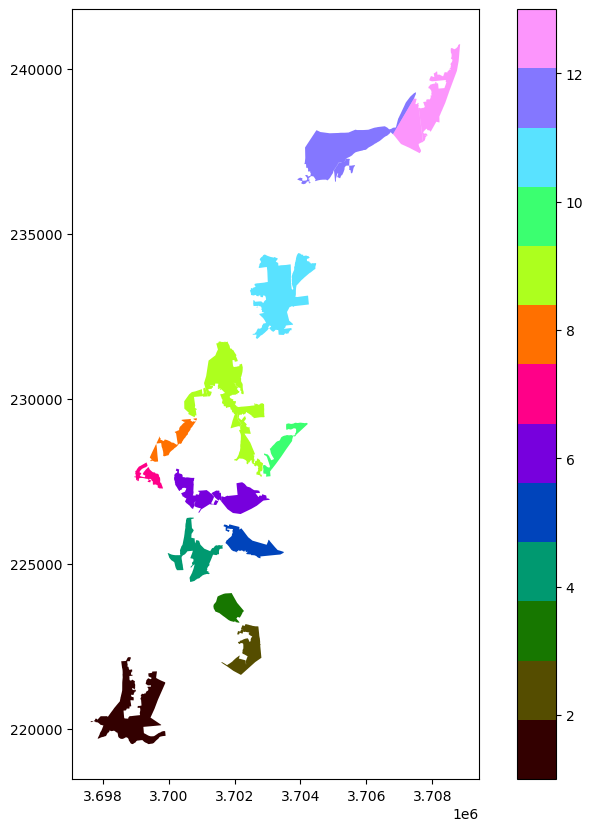

In [212]:
# replace the shapes with the dissolved shapes from the original kml
parcel_gdf["geometry"] = suggested_parcels_gdf["geometry"].buffer(10)
parcel_gdf = gpd.GeoDataFrame(parcel_gdf, geometry="geometry").set_crs(INDIA_PROJECTED_CRS)
parcel_gdf.plot(
    column="Parcel Name",
    cmap=ListedColormap(generate_colormap(len(parcel_gdf))),
    figsize=(10, 10),
    legend=True,
)

In [213]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Sgurr Parcel Shapefiles",
    "Parcels",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 215.03.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 85.959999999999994.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 50.630000000000003.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 99.439999999999998.
  ogr_write(
/Use